# VGG16 — 20 epochs

Training and evaluation of a VGG16 transfer-learning model for binary tuberculosis classification from chest X-ray images.

**Dataset path expected:** `data/TB_Chest_Radiography_Database/`.


Train size: 4900, Validation size: 1050, Test size: 1050
Found 4900 validated image filenames.
Found 1050 validated image filenames.
Found 1050 validated image filenames.
Epoch 1/20


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


154/154 ━━━━━━━━━━━━━━━━━━━━ 2271s 15s/step - accuracy: 0.8176 - loss: 0.3673 - val_accuracy: 0.9029 - val_loss: 0.2188
Epoch 2/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 2140s 14s/step - accuracy: 0.9581 - loss: 0.1104 - val_accuracy: 0.9876 - val_loss: 0.0397
Epoch 3/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 1980s 13s/step - accuracy: 0.9812 - loss: 0.0590 - val_accuracy: 0.9648 - val_loss: 0.0977
Epoch 4/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 1914s 12s/step - accuracy: 0.9688 - loss: 0.0920 - val_accuracy: 0.9924 - val_loss: 0.0334
Epoch 5/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 1953s 13s/step - accuracy: 0.9864 - loss: 0.0398 - val_accuracy: 0.9810 - val_loss: 0.0723
Epoch 6/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 3074s 20s/step - accuracy: 0.9854 - loss: 0.0449 - val_accuracy: 0.9905 - val_loss: 0.0371
Epoch 7/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 5496s 36s/step - accuracy: 0.9841 - loss: 0.0422 - val_accuracy: 0.9724 - val_loss: 0.0876
Epoch 8/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 4055s 26s/step - accuracy: 0.9886 - loss: 0.0437 - val

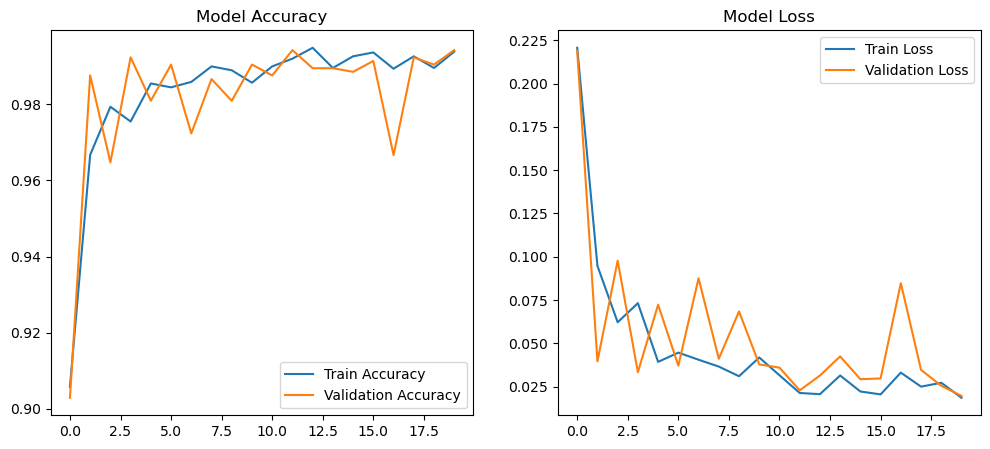

33/33 ━━━━━━━━━━━━━━━━━━━━ 273s 8s/step - accuracy: 0.9926 - loss: 0.0207
Test Accuracy: 99.52%
Test Loss: 0.0284
33/33 ━━━━━━━━━━━━━━━━━━━━ 274s 8s/step


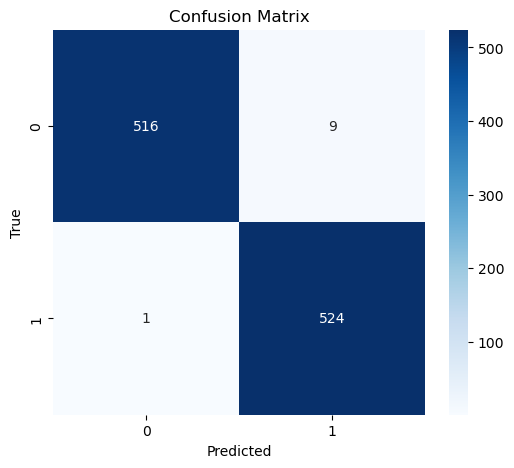


Classification Report:
               precision    recall  f1-score   support

      Normal       1.00      0.98      0.99       525
          TB       0.98      1.00      0.99       525

    accuracy                           0.99      1050
   macro avg       0.99      0.99      0.99      1050
weighted avg       0.99      0.99      0.99      1050



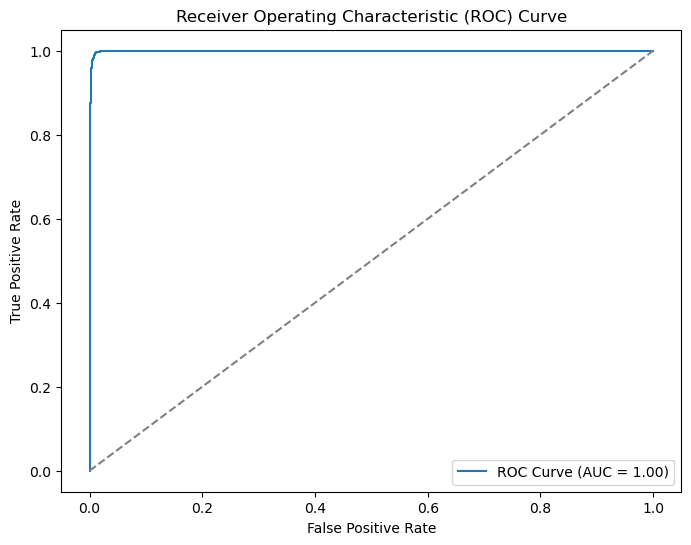

In [ ]:
## 20 Epochs VGG16 ##
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight

# Step 1: Define dataset path
base_path = r'data/TB_Chest_Radiography_Database'

# Step 2: Load and preprocess data
image_paths = []
labels = []

# Define categories
categories = ['Normal', 'Tuberculosis']

# Loop through directories and collect image paths and labels
for category in categories:
    folder_path = os.path.join(base_path, category)
    for file in os.listdir(folder_path):
        image_paths.append(os.path.join(folder_path, file))
        labels.append(category)

# Step 3: Create DataFrame #
df = pd.DataFrame({'image_path': image_paths, 'label': labels})
df['label'] = df['label'].map({'Normal': 0, 'Tuberculosis': 1})  # Convert labels to binary (0,1)

# Step 4: Split dataset (Train 70%, Validation 15%, Test 15%)
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

print(f"Train size: {len(train_df)}, Validation size: {len(val_df)}, Test size: {len(test_df)}")

# Step 5: Data Augmentation #
data_gen = ImageDataGenerator(
    rescale=1./255, 
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Step 6: Create Image Generators
train_generator = data_gen.flow_from_dataframe(
    train_df, x_col='image_path', y_col='label', target_size=(224, 224), batch_size=32,
    class_mode='raw', shuffle=True
)

val_generator = data_gen.flow_from_dataframe(
    val_df, x_col='image_path', y_col='label', target_size=(224, 224), batch_size=32,
    class_mode='raw', shuffle=False
)

test_generator = data_gen.flow_from_dataframe(
    test_df, x_col='image_path', y_col='label', target_size=(224, 224), batch_size=32,
    class_mode='raw', shuffle=False
)

# Step 7: Load VGG16 (Pretrained)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Fine-tune: Unfreeze last 4 layers
for layer in base_model.layers[:-4]:  
    layer.trainable = False

########Step 8: Build the Model
model = Sequential([
    base_model,
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary classification
])

##Step 9: Compile Model#

model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

# Step 10: Train Model
history = model.fit(train_generator, validation_data=val_generator, epochs=20)

# Step 11: Plot Training History
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')

plt.show()
# Step 12: Evaluate on Test Set #
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")  # Added test loss output

# Step 13: Confusion Matrix & Classification Report
y_true = test_df['label'].values  
y_pred_probs = model.predict(test_generator)
y_pred = (y_pred_probs > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=['Normal', 'TB']))

#Step 14: ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()


In [2]:
# Save the model trained for 20 epochs
model.save("tb_vgg16_20epochs.h5")
print("✅ Model saved as tb_vgg16_20epochs.h5")


✅ Model saved as tb_vgg16_20epochs.h5
